# TT-Shape Parameter Space Notebook

This notebook lets us explore the TT-shape parameter space for a given TT-LoRA rank, weight shape, and adaptation pattern.

It will:
- enumerate all possible TT shapes
- save the full shape table
- save the lowest-parameter shape for each total core count
- save the highest-parameter shape for each total core count
- save summary metadata and plots
- show a few inline plots for quick inspection


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd

phase_root = Path('/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study')
script_dir = phase_root / 'scripts'
if str(script_dir) not in sys.path:
    sys.path.insert(0, str(script_dir))

from analyze_tt_shape_parameter_space import (
    build_parameter_space,
    plot_all_shape_parameter_scatter,
    plot_shape_count_and_param_bounds,
    plot_range_width,
    write_csv,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_rows', 50)


## Parameters

Set the experimental configuration here, then run the notebook top to bottom.

- `weight_shape` should be `(out_features, in_features)` when you want a rectangular weight.
- If `weight_shape` is `None`, the notebook uses the square `weight_dim x weight_dim` case.


In [7]:
# Core experiment settings
rank = 6
model_name = "llama3.2-1b_qo"  # Example: "gpt2small", "llama2-7b"
weight_shape = (2048, 2048)  # Example: (2304, 3072)
adapted_weights_per_layer = 2
num_layers = 16

weight_dim = 768

# Enumeration settings
split_strategy = 'all'
allow_one_factors = False
core_counts = None  # Example: [4, 6, 8, 10]

# Output settings
output_dir = phase_root / 'analysis' / f'parameter_space_notebook_{model_name}'
output_dir.mkdir(parents=True, exist_ok=True)

if weight_shape is not None:
    out_features, in_features = weight_shape
else:
    in_features = weight_dim
    out_features = weight_dim

print({
    'rank': rank,
    'weight_shape': [out_features, in_features],
    'adapted_weights_per_layer': adapted_weights_per_layer,
    'num_layers': num_layers,
    'split_strategy': split_strategy,
    'allow_one_factors': allow_one_factors,
    'core_counts': core_counts,
    'output_dir': str(output_dir),
})


{'rank': 6, 'weight_shape': [2048, 2048], 'adapted_weights_per_layer': 2, 'num_layers': 16, 'split_strategy': 'all', 'allow_one_factors': False, 'core_counts': None, 'output_dir': '/home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo'}


## Build Parameter Space And Save Outputs

In [8]:
raw_rows, summary_rows, min_rows, max_rows = build_parameter_space(
    in_features=in_features,
    out_features=out_features,
    rank=rank,
    split_strategy=split_strategy,
    allow_one_factors=allow_one_factors,
    core_counts=tuple(core_counts) if core_counts else None,
    qkv_multiplier=adapted_weights_per_layer,
    layer_multiplier=num_layers,
)

metadata = {
    'weight_shape': [out_features, in_features],
    'rank': rank,
    'adapted_weights_per_layer': adapted_weights_per_layer,
    'num_layers': num_layers,
    'split_strategy': split_strategy,
    'allow_one_factors': allow_one_factors,
    'num_shapes': len(raw_rows),
    'num_core_counts': len(summary_rows),
}

all_shapes_csv = output_dir / 'all_shapes_parameter_counts.csv'
lowest_shapes_csv = output_dir / 'lowest_parameter_shapes_by_core_count.csv'
highest_shapes_csv = output_dir / 'highest_parameter_shapes_by_core_count.csv'
bounds_csv = output_dir / 'parameter_bounds_by_core_count.csv'
metadata_json = output_dir / 'parameter_space_metadata.json'

bounds_plot = output_dir / 'shape_count_and_parameter_bounds.svg'
scatter_plot = output_dir / 'all_shape_parameter_scatter.svg'
diversity_plot = output_dir / 'parameter_space_diversity.svg'

write_csv(all_shapes_csv, raw_rows)
write_csv(lowest_shapes_csv, min_rows)
write_csv(highest_shapes_csv, max_rows)
write_csv(bounds_csv, summary_rows)
metadata_json.write_text(json.dumps(metadata, indent=2, sort_keys=True), encoding='utf-8')

plot_shape_count_and_param_bounds(summary_rows, bounds_plot)
plot_all_shape_parameter_scatter(raw_rows, scatter_plot)
plot_range_width(summary_rows, diversity_plot)

print('Saved outputs to:', output_dir)
print('  all shapes     ->', all_shapes_csv)
print('  lowest shapes  ->', lowest_shapes_csv)
print('  highest shapes ->', highest_shapes_csv)
print('  bounds         ->', bounds_csv)
print('  metadata       ->', metadata_json)
print('  plots          ->', bounds_plot, scatter_plot, diversity_plot, sep='\n                   ')


Saved outputs to: /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo
  all shapes     -> /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/all_shapes_parameter_counts.csv
  lowest shapes  -> /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/lowest_parameter_shapes_by_core_count.csv
  highest shapes -> /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/highest_parameter_shapes_by_core_count.csv
  bounds         -> /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/parameter_bounds_by_core_count.csv
  metadata       -> /home/pkunwar/characterize_ttlora/phases/2.1.ttlora_core_count_study/analysis/parameter_space_notebook_llama3.2-1b_qo/parameter_space_metada

## Load Saved CSVs

In [59]:
df_all = pd.read_csv(all_shapes_csv)
df_low = pd.read_csv(lowest_shapes_csv)
df_high = pd.read_csv(highest_shapes_csv)
df_bounds = pd.read_csv(bounds_csv)

print('All shapes:', len(df_all))
print('Core-count rows:', len(df_bounds))

df_bounds


All shapes: 10485760
Core-count rows: 18


,weight_shape,in_features,out_features,adapted_weights_per_layer,num_layers,total_cores,num_shapes,num_unique_total_param_counts,min_total_params,max_total_params,min_per_matrix_params,max_per_matrix_params,min_shape,max_shape,min_input_factors,min_output_factors,max_input_factors,max_output_factors
0,"[2304, 768]",768,2304,1,12,2,1,1,221184,221184,18432,18432,"[768, 2304]","[768, 2304]",[768],[2304],[768],[2304]
1,"[2304, 768]",768,2304,1,12,3,41,30,72288,553104,6024,46092,"[768, 18, 128]","[768, 1152, 2]",[768],"[128, 18]",[768],"[2, 1152]"
2,"[2304, 768]",768,2304,1,12,4,676,298,26784,663840,2232,55320,"[64, 12, 18, 128]","[2, 384, 1152, 2]","[64, 12]","[128, 18]","[2, 384]","[2, 1152]"
3,"[2304, 768]",768,2304,1,12,5,6124,1043,19296,581760,1608,48480,"[64, 12, 8, 6, 48]","[2, 2, 192, 1152, 2]","[64, 12]","[48, 6, 8]","[2, 2, 192]","[2, 1152]"
4,"[2304, 768]",768,2304,1,12,6,35336,1574,16128,541152,1344,45096,"[32, 4, 6, 8, 6, 48]","[2, 2, 2, 96, 1152, 2]","[32, 4, 6]","[48, 6, 8]","[2, 2, 2, 96]","[2, 1152]"
5,"[2304, 768]",768,2304,1,12,7,141232,1511,14400,521280,1200,43440,"[32, 4, 6, 4, 4, 4, 36]","[2, 2, 2, 2, 48, 1152, 2]","[32, 4, 6]","[36, 4, 4, 4]","[2, 2, 2, 2, 48]","[2, 1152]"
6,"[2304, 768]",768,2304,1,12,8,411684,1262,13680,511776,1140,42648,"[16, 3, 4, 4, 4, 4, 4, 36]","[2, 2, 2, 2, 2, 24, 1152, 2]","[16, 3, 4, 4]","[36, 4, 4, 4]","[2, 2, 2, 2, 2, 24]","[2, 1152]"
7,"[2304, 768]",768,2304,1,12,9,904332,1011,13104,507456,1092,42288,"[16, 3, 4, 4, 4, 4, 3, 3, 16]","[2, 2, 2, 2, 2, 2, 12, 1152, 2]","[16, 3, 4, 4]","[16, 3, 3, 4, 4]","[2, 2, 2, 2, 2, 2, 12]","[2, 1152]"
8,"[2304, 768]",768,2304,1,12,10,1528098,764,13104,505728,1092,42144,"[16, 3, 4, 4, 4, 3, 3, 2, 2, 16]","[2, 2, 2, 2, 2, 2, 2, 6, 1152, 2]","[16, 3, 4, 4]","[16, 2, 2, 3, 3, 4]","[2, 2, 2, 2, 2, 2, 2, 6]","[2, 1152]"
9,"[2304, 768]",768,2304,1,12,11,2009722,571,13104,505296,1092,42108,"[16, 3, 4, 4, 3, 3, 2, 2, 2, 2, 16]","[2, 2, 2, 2, 2, 2, 2, 2, 3, 1152, 2]","[16, 3, 4, 4]","[16, 2, 2, 2, 2, 3, 3]","[2, 2, 2, 2, 2, 2, 2, 2, 3]","[2, 1152]"


## Lowest And Highest Parameter Shapes

In [60]:
display(df_low)
display(df_high)


,weight_shape,in_features,out_features,adapted_weights_per_layer,num_layers,total_cores,num_shapes,num_unique_total_param_counts,all_layers_qkv_params,per_layer_qkv_params,per_matrix_params,input_cores,output_cores,input_factors,output_factors,tt_shape
0,"[2304, 768]",768,2304,1,12,2,1,1,221184,18432,18432,1,1,[768],[2304],"[768, 2304]"
1,"[2304, 768]",768,2304,1,12,3,41,30,72288,6024,6024,1,2,[768],"[128, 18]","[768, 18, 128]"
2,"[2304, 768]",768,2304,1,12,4,676,298,26784,2232,2232,2,2,"[64, 12]","[128, 18]","[64, 12, 18, 128]"
3,"[2304, 768]",768,2304,1,12,5,6124,1043,19296,1608,1608,2,3,"[64, 12]","[48, 6, 8]","[64, 12, 8, 6, 48]"
4,"[2304, 768]",768,2304,1,12,6,35336,1574,16128,1344,1344,3,3,"[32, 4, 6]","[48, 6, 8]","[32, 4, 6, 8, 6, 48]"
5,"[2304, 768]",768,2304,1,12,7,141232,1511,14400,1200,1200,3,4,"[32, 4, 6]","[36, 4, 4, 4]","[32, 4, 6, 4, 4, 4, 36]"
6,"[2304, 768]",768,2304,1,12,8,411684,1262,13680,1140,1140,4,4,"[16, 3, 4, 4]","[36, 4, 4, 4]","[16, 3, 4, 4, 4, 4, 4, 36]"
7,"[2304, 768]",768,2304,1,12,9,904332,1011,13104,1092,1092,4,5,"[16, 3, 4, 4]","[16, 3, 3, 4, 4]","[16, 3, 4, 4, 4, 4, 3, 3, 16]"
8,"[2304, 768]",768,2304,1,12,10,1528098,764,13104,1092,1092,4,6,"[16, 3, 4, 4]","[16, 2, 2, 3, 3, 4]","[16, 3, 4, 4, 4, 3, 3, 2, 2, 16]"
9,"[2304, 768]",768,2304,1,12,11,2009722,571,13104,1092,1092,4,7,"[16, 3, 4, 4]","[16, 2, 2, 2, 2, 3, 3]","[16, 3, 4, 4, 3, 3, 2, 2, 2, 2, 16]"


,weight_shape,in_features,out_features,adapted_weights_per_layer,num_layers,total_cores,num_shapes,num_unique_total_param_counts,all_layers_qkv_params,per_layer_qkv_params,per_matrix_params,input_cores,output_cores,input_factors,output_factors,tt_shape
0,"[2304, 768]",768,2304,1,12,2,1,1,221184,18432,18432,1,1,[768],[2304],"[768, 2304]"
1,"[2304, 768]",768,2304,1,12,3,41,30,553104,46092,46092,1,2,[768],"[2, 1152]","[768, 1152, 2]"
2,"[2304, 768]",768,2304,1,12,4,676,298,663840,55320,55320,2,2,"[2, 384]","[2, 1152]","[2, 384, 1152, 2]"
3,"[2304, 768]",768,2304,1,12,5,6124,1043,581760,48480,48480,3,2,"[2, 2, 192]","[2, 1152]","[2, 2, 192, 1152, 2]"
4,"[2304, 768]",768,2304,1,12,6,35336,1574,541152,45096,45096,4,2,"[2, 2, 2, 96]","[2, 1152]","[2, 2, 2, 96, 1152, 2]"
5,"[2304, 768]",768,2304,1,12,7,141232,1511,521280,43440,43440,5,2,"[2, 2, 2, 2, 48]","[2, 1152]","[2, 2, 2, 2, 48, 1152, 2]"
6,"[2304, 768]",768,2304,1,12,8,411684,1262,511776,42648,42648,6,2,"[2, 2, 2, 2, 2, 24]","[2, 1152]","[2, 2, 2, 2, 2, 24, 1152, 2]"
7,"[2304, 768]",768,2304,1,12,9,904332,1011,507456,42288,42288,7,2,"[2, 2, 2, 2, 2, 2, 12]","[2, 1152]","[2, 2, 2, 2, 2, 2, 12, 1152, 2]"
8,"[2304, 768]",768,2304,1,12,10,1528098,764,505728,42144,42144,8,2,"[2, 2, 2, 2, 2, 2, 2, 6]","[2, 1152]","[2, 2, 2, 2, 2, 2, 2, 6, 1152, 2]"
9,"[2304, 768]",768,2304,1,12,11,2009722,571,505296,42108,42108,9,2,"[2, 2, 2, 2, 2, 2, 2, 2, 3]","[2, 1152]","[2, 2, 2, 2, 2, 2, 2, 2, 3, 1152, 2]"


## Inline Plots

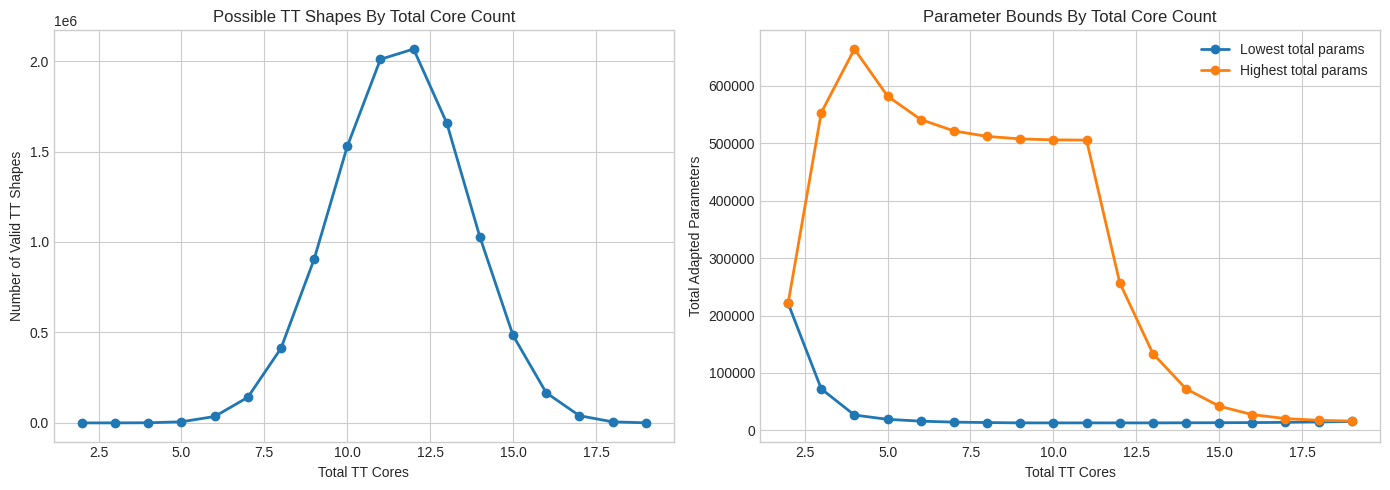

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_bounds['total_cores'], df_bounds['num_shapes'], marker='o', linewidth=2)
axes[0].set_title('Possible TT Shapes By Total Core Count')
axes[0].set_xlabel('Total TT Cores')
axes[0].set_ylabel('Number of Valid TT Shapes')

axes[1].plot(df_bounds['total_cores'], df_bounds['min_total_params'], marker='o', linewidth=2, label='Lowest total params')
axes[1].plot(df_bounds['total_cores'], df_bounds['max_total_params'], marker='o', linewidth=2, label='Highest total params')
axes[1].set_title('Parameter Bounds By Total Core Count')
axes[1].set_xlabel('Total TT Cores')
axes[1].set_ylabel('Total Adapted Parameters')
axes[1].legend()

fig.tight_layout()
plt.show()


/tmp/ipykernel_1476706/2381507276.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()
/home/pkunwar/miniconda3/envs/rag/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


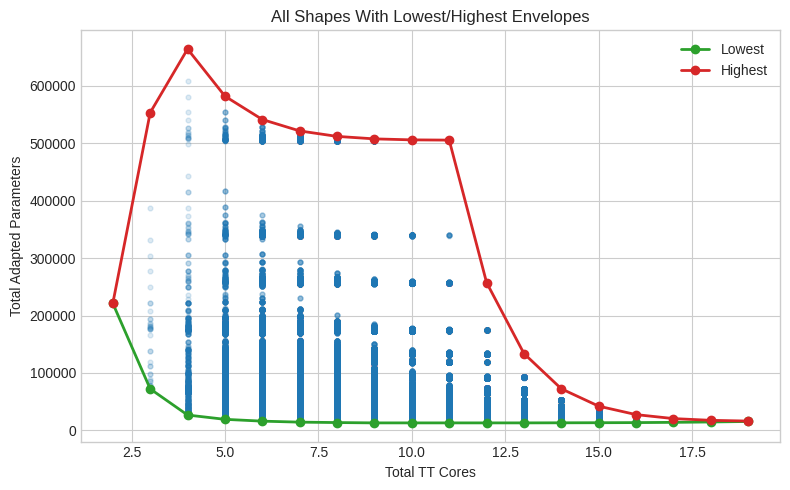

In [62]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(
    df_all['total_cores'],
    df_all['all_layers_qkv_params'],
    alpha=0.15,
    s=12,
    color='#1f77b4',
)
ax.plot(df_low['total_cores'], df_low['all_layers_qkv_params'], color='#2ca02c', linewidth=2, marker='o', label='Lowest')
ax.plot(df_high['total_cores'], df_high['all_layers_qkv_params'], color='#d62728', linewidth=2, marker='o', label='Highest')
ax.set_title('All Shapes With Lowest/Highest Envelopes')
ax.set_xlabel('Total TT Cores')
ax.set_ylabel('Total Adapted Parameters')
ax.legend()
fig.tight_layout()
plt.show()


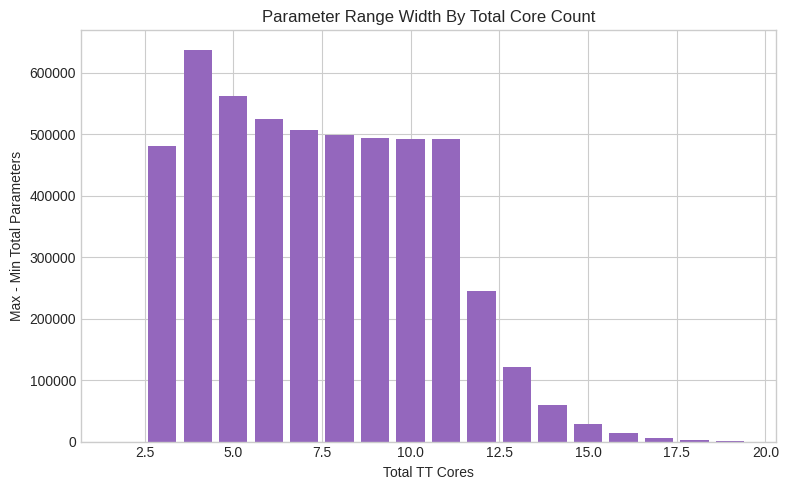

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
range_width = df_bounds['max_total_params'] - df_bounds['min_total_params']
ax.bar(df_bounds['total_cores'], range_width, color='#9467bd')
ax.set_title('Parameter Range Width By Total Core Count')
ax.set_xlabel('Total TT Cores')
ax.set_ylabel('Max - Min Total Parameters')
fig.tight_layout()
plt.show()
